In [ ]:
# Uncomment khi chạy trên Colab (nhớ Restart Session sau khi cài):
!pip install transformers[torch] datasets Pillow jiwer tqdm matplotlib seaborn sentencepiece "numpy<2.0.0"

In [ ]:
!pip install huggingface_hub

from huggingface_hub import login
# login(token="type_token_here")


In [ ]:
# PHƯƠNG ÁN 2: TrOCR (Kiến trúc Transformer thuần — ViT + RoBERTa)


# PHẦN 1: CÀI ĐẶT THƯ VIỆN


import os
import sys
import time
import csv
import json
import torch
import numpy as np
from PIL import Image
from tqdm import tqdm
from datetime import datetime
from collections import Counter

from jiwer import wer as compute_wer
from transformers import (
    TrOCRProcessor,
    VisionEncoderDecoderModel,
    Seq2SeqTrainer,
    Seq2SeqTrainingArguments,
    default_data_collator,
)
from torch.utils.data import Dataset as TorchDataset
from datasets import load_dataset
import matplotlib.pyplot as plt
import matplotlib
matplotlib.use('Agg')
import seaborn as sns


In [ ]:

# PHẦN 2: CẤU HÌNH
class Config:
    DATASET_NAME = "5CD-AI/Viet-Handwriting-OCR-v2"
    MODEL_NAME = "microsoft/trocr-base-handwritten"
    MAX_TARGET_LENGTH = 128

    DO_TRAIN = False
    NUM_EPOCHS = 1
    BATCH_SIZE = 8
    LEARNING_RATE = 5e-5
    WARMUP_STEPS = 500
    WEIGHT_DECAY = 0.01
    EVAL_STEPS = 1000
    SAVE_STEPS = 1000
    LOGGING_STEPS = 50
    FP16 = True
    NUM_TRAIN_SAMPLES = None
    NUM_TEST_SAMPLES = 1000
    NUM_BEAMS = 4

    DEVICE = "cuda:0" if torch.cuda.is_available() else "cpu"

    OUTPUT_DIR = "results_trocr"
    MODEL_SAVE_PATH = "results_trocr/checkpoint_best"
    RESULTS_CSV = "results_trocr/predictions.csv"
    METRICS_JSON = "results_trocr/metrics.json"

    @classmethod
    def setup(cls):
        os.makedirs(cls.OUTPUT_DIR, exist_ok=True)
        print(f"[CONFIG] Device: {cls.DEVICE}")
        print(f"[CONFIG] Model: {cls.MODEL_NAME}")
        print(f"[CONFIG] Fine-tune: {cls.DO_TRAIN}")
        print(f"[CONFIG] FP16: {cls.FP16}, Batch: {cls.BATCH_SIZE}")
        if torch.cuda.is_available():
            print(f"[CONFIG] GPU: {torch.cuda.get_device_name(0)}")
            print(f"[CONFIG] VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

In [ ]:
# PHẦN 3: HÀM TÍNH METRICS
def levenshtein_distance(s1: str, s2: str) -> int:
    if len(s1) == 0: return len(s2)
    if len(s2) == 0: return len(s1)
    d = np.zeros((len(s1) + 1, len(s2) + 1), dtype=int)
    for i in range(len(s1) + 1): d[i][0] = i
    for j in range(len(s2) + 1): d[0][j] = j
    for i in range(1, len(s1) + 1):
        for j in range(1, len(s2) + 1):
            if s1[i-1] == s2[j-1]:
                d[i][j] = d[i-1][j-1]
            else:
                d[i][j] = min(d[i-1][j]+1, d[i][j-1]+1, d[i-1][j-1]+1)
    return d[len(s1)][len(s2)]


def compute_cer(prediction: str, ground_truth: str) -> float:
    if len(ground_truth) == 0:
        return 0.0 if len(prediction) == 0 else 1.0
    return levenshtein_distance(prediction, ground_truth) / len(ground_truth)


def compute_char_precision_recall_f1(prediction: str, ground_truth: str):
    """Precision, Recall, F1 ở mức ký tự (character-level bag-of-chars)."""
    if len(prediction) == 0 and len(ground_truth) == 0:
        return 1.0, 1.0, 1.0
    if len(prediction) == 0: return 0.0, 0.0, 0.0
    if len(ground_truth) == 0: return 0.0, 0.0, 0.0

    pred_counter = Counter(prediction)
    gt_counter = Counter(ground_truth)
    overlap = sum(min(pred_counter[c], gt_counter.get(c, 0)) for c in pred_counter)

    precision = overlap / len(prediction)
    recall = overlap / len(ground_truth)
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
    return precision, recall, f1


def compute_metrics_all(predictions: list, ground_truths: list) -> dict:
    """Tính toàn bộ metrics."""
    assert len(predictions) == len(ground_truths)

    cer_scores = [compute_cer(p, g) for p, g in zip(predictions, ground_truths)]

    valid_pairs = [(p, g) for p, g in zip(predictions, ground_truths) if len(g.strip()) > 0]
    avg_wer = compute_wer([g for _, g in valid_pairs], [p for p, _ in valid_pairs]) if valid_pairs else 0.0

    exact_matches = sum(1 for p, g in zip(predictions, ground_truths) if p.strip() == g.strip())

    precisions, recalls, f1s = [], [], []
    for pred, gt in zip(predictions, ground_truths):
        p, r, f = compute_char_precision_recall_f1(pred, gt)
        precisions.append(p); recalls.append(r); f1s.append(f)

    return {
        "cer": round(np.mean(cer_scores), 4),
        "wer": round(avg_wer, 4),
        "accuracy": round(exact_matches / len(predictions), 4),
        "precision": round(np.mean(precisions), 4),
        "recall": round(np.mean(recalls), 4),
        "f1_score": round(np.mean(f1s), 4),
        "exact_matches": exact_matches,
        "total_samples": len(predictions),
        "cer_scores": cer_scores,
    }


def get_gpu_memory_info():
    if torch.cuda.is_available():
        return {
            "allocated_gb": round(torch.cuda.memory_allocated() / 1e9, 2),
            "reserved_gb": round(torch.cuda.memory_reserved() / 1e9, 2),
            "total_gb": round(torch.cuda.get_device_properties(0).total_memory / 1e9, 2),
        }
    return {"allocated_gb": 0, "reserved_gb": 0, "total_gb": 0}


def count_parameters(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable


In [ ]:
# PHẦN 4: LOAD DATASET
def load_data(config):
    print("\n" + "=" * 60)
    print("ĐANG TẢI DATASET...")
    print("=" * 60)
    dataset = load_dataset(config.DATASET_NAME)
    train_data = dataset["train"]
    test_data = dataset["test"]
    if config.NUM_TRAIN_SAMPLES:
        train_data = train_data.select(range(min(config.NUM_TRAIN_SAMPLES, len(train_data))))
    if config.NUM_TEST_SAMPLES:
        test_data = test_data.select(range(min(config.NUM_TEST_SAMPLES, len(test_data))))
    print(f"[DATA] Train: {len(train_data)}, Test: {len(test_data)}")
    return train_data, test_data


In [ ]:
# PHẦN 5: CUSTOM DATASET

class TrOCRDataset(TorchDataset):
    def __init__(self, hf_dataset, processor, max_target_length=128):
        self.dataset = hf_dataset
        self.processor = processor
        self.max_target_length = max_target_length

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        sample = self.dataset[idx]
        image = sample["image"]
        if image.mode != "RGB":
            image = image.convert("RGB")

        pixel_values = self.processor(images=image, return_tensors="pt").pixel_values.squeeze()
        labels = self.processor.tokenizer(
            sample["text"], padding="max_length",
            max_length=self.max_target_length, truncation=True,
            return_tensors="pt"
        ).input_ids.squeeze()
        labels[labels == self.processor.tokenizer.pad_token_id] = -100

        return {"pixel_values": pixel_values, "labels": labels}

In [ ]:
# PHẦN 6: TrOCR MODEL WRAPPER
class TrOCRWrapper:
    def __init__(self, config):
        self.config = config

        print(f"[MODEL] Đang tải TrOCR từ {config.MODEL_NAME}...")
        self.processor = TrOCRProcessor.from_pretrained(config.MODEL_NAME)
        import os
        from transformers.trainer_utils import get_last_checkpoint

        last_checkpoint = None
        if os.path.isdir(config.MODEL_SAVE_PATH):
            last_checkpoint = get_last_checkpoint(config.MODEL_SAVE_PATH)
        if last_checkpoint is None:
            if os.path.isdir('/content/drive/MyDrive/checkpoint-3000'):
                last_checkpoint = '/content/drive/MyDrive/checkpoint-3000'
            elif os.path.isdir('/content/drive/MyDrive'):
                last_checkpoint = get_last_checkpoint('/content/drive/MyDrive')

        if last_checkpoint is not None:
            print(f"[MODEL] Tìm thấy checkpoint: {last_checkpoint}. Khởi tạo mô hình từ đây...")
            self.model = VisionEncoderDecoderModel.from_pretrained(last_checkpoint)
        else:
            self.model = VisionEncoderDecoderModel.from_pretrained(config.MODEL_NAME)

        self.model.config.decoder_start_token_id = self.processor.tokenizer.cls_token_id
        self.model.config.pad_token_id = self.processor.tokenizer.pad_token_id
        self.model.config.vocab_size = self.model.config.decoder.vocab_size

        if not hasattr(self.model, "generation_config"):
            from transformers import GenerationConfig
            self.model.generation_config = GenerationConfig.from_model_config(self.model.config)

        self.model.generation_config.max_length = config.MAX_TARGET_LENGTH
        self.model.generation_config.num_beams = config.NUM_BEAMS
        self.model.generation_config.decoder_start_token_id = self.processor.tokenizer.cls_token_id
        self.model.generation_config.pad_token_id = self.processor.tokenizer.pad_token_id

        self.model.to(config.DEVICE)


        self.total_params, self.trainable_params = count_parameters(self.model)
        self.vram_after_load = get_gpu_memory_info()
        self.train_losses = []
        self.val_losses = []
        self.training_time_seconds = 0
        self.vram_peak_training = 0

        print(f"[MODEL] TrOCR loaded")
        print(f"[MODEL] Tổng params     : {self.total_params:,}")
        print(f"[MODEL] Trainable params: {self.trainable_params:,}")
        print(f"[MODEL] VRAM sau load   : {self.vram_after_load['allocated_gb']:.2f} GB")

    def predict(self, image):
        if image.mode != "RGB":
            image = image.convert("RGB")
        pixel_values = self.processor(images=image, return_tensors="pt").pixel_values.to(self.config.DEVICE)
        with torch.no_grad():
            ids = self.model.generate(pixel_values, max_length=self.config.MAX_TARGET_LENGTH,
                                      num_beams=self.config.NUM_BEAMS)
        return self.processor.batch_decode(ids, skip_special_tokens=True)[0]

    def fine_tune(self, train_data, test_data):
        """Fine-tune TrOCR với Seq2SeqTrainer — theo dõi Loss."""
        print("\n" + "=" * 60)
        print("FINE-TUNING TrOCR...")
        print("=" * 60)

        train_dataset = TrOCRDataset(train_data, self.processor, self.config.MAX_TARGET_LENGTH)
        eval_dataset = TrOCRDataset(test_data, self.processor, self.config.MAX_TARGET_LENGTH)
        print(f"[TRAIN] Train: {len(train_dataset)}, Eval: {len(eval_dataset)}")

        training_args = Seq2SeqTrainingArguments(
            output_dir=self.config.MODEL_SAVE_PATH,
            per_device_train_batch_size=self.config.BATCH_SIZE,
            per_device_eval_batch_size=self.config.BATCH_SIZE,
            num_train_epochs=self.config.NUM_EPOCHS,
            learning_rate=self.config.LEARNING_RATE,
            warmup_steps=self.config.WARMUP_STEPS,
            weight_decay=self.config.WEIGHT_DECAY,
            fp16=self.config.FP16,
            eval_strategy="steps",
            eval_steps=self.config.EVAL_STEPS,
            save_steps=self.config.SAVE_STEPS,
            save_total_limit=2,
            logging_steps=self.config.LOGGING_STEPS,
            logging_dir=os.path.join(self.config.OUTPUT_DIR, "logs"),
            predict_with_generate=True,
            load_best_model_at_end=True,
            metric_for_best_model="eval_loss",
            greater_is_better=False,
            report_to="none",
            dataloader_num_workers=2,
            remove_unused_columns=False,
        )

        def compute_metrics_fn(pred):
            pred_ids = pred.predictions
            label_ids = pred.label_ids
            pred_str = self.processor.batch_decode(pred_ids, skip_special_tokens=True)
            label_ids[label_ids == -100] = self.processor.tokenizer.pad_token_id
            label_str = self.processor.batch_decode(label_ids, skip_special_tokens=True)
            cer_list = [compute_cer(p, g) for p, g in zip(pred_str, label_str)]
            return {"cer": np.mean(cer_list)}

        trainer = Seq2SeqTrainer(
            model=self.model, args=training_args,
            train_dataset=train_dataset, eval_dataset=eval_dataset,
            compute_metrics=compute_metrics_fn,
            data_collator=default_data_collator,
        )

        print(f"[TRAIN] Epochs: {self.config.NUM_EPOCHS}, LR: {self.config.LEARNING_RATE}")


        if torch.cuda.is_available():
            torch.cuda.reset_peak_memory_stats()

        train_start = time.time()
        print("[TRAIN] Bắt đầu training (tiếp tục học từ trọng số hiện tại)...")
        train_result = trainer.train()
        train_end = time.time()

        self.training_time_seconds = round(train_end - train_start, 2)

        for log_entry in trainer.state.log_history:
            if "loss" in log_entry and "eval_loss" not in log_entry:
                self.train_losses.append(log_entry["loss"])
            if "eval_loss" in log_entry:
                self.val_losses.append(log_entry["eval_loss"])

        # VRAM peak
        if torch.cuda.is_available():
            self.vram_peak_training = round(torch.cuda.max_memory_allocated() / 1e9, 2)

        # Lưu model
        trainer.save_model(self.config.MODEL_SAVE_PATH)
        self.processor.save_pretrained(self.config.MODEL_SAVE_PATH)

        # Lưu training log
        log_path = os.path.join(self.config.OUTPUT_DIR, "training_log.json")
        with open(log_path, "w") as f:
            json.dump(trainer.state.log_history, f, indent=2)

        print(f"\n[TRAIN] Fine-tune hoàn tất!")
        print(f"[TRAIN]  Thời gian: {self.training_time_seconds:.2f}s ({self.training_time_seconds/60:.1f} phút)")
        print(f"[TRAIN]  Final train loss: {train_result.training_loss:.4f}")
        print(f"[TRAIN]  VRAM peak: {self.vram_peak_training:.2f} GB")
        print(f"[TRAIN]  Train loss points: {len(self.train_losses)}")
        print(f"[TRAIN]  Val loss points  : {len(self.val_losses)}")



In [ ]:
# PHẦN 7: ĐÁNH GIÁ MÔ HÌNH

def evaluate_model(model, test_data, config):
    print("\n" + "=" * 60)
    print("ĐÁNH GIÁ MÔ HÌNH TrOCR")
    print("=" * 60)

    model.model.eval()
    predictions, ground_truths, inference_times = [], [], []

    for idx, sample in enumerate(tqdm(test_data, desc="Đang đánh giá")):
        start = time.time()
        pred = model.predict(sample["image"])
        elapsed = time.time() - start

        predictions.append(pred)
        ground_truths.append(sample["text"])
        inference_times.append(elapsed)

        if idx < 5:
            print(f"\n  Mẫu {idx+1}: GT='{sample['text']}' → Pred='{pred}' ({elapsed*1000:.1f}ms)")

    vram_peak = round(torch.cuda.max_memory_allocated() / 1e9, 2) if torch.cuda.is_available() else 0

    metrics = compute_metrics_all(predictions, ground_truths)
    metrics.update({
        "avg_inference_time_ms": round(np.mean(inference_times) * 1000, 2),
        "total_inference_time_s": round(sum(inference_times), 2),
        "model_name": "TrOCR (ViT + RoBERTa)",
        "model_type": "Transformer",
        "total_params": model.total_params,
        "trainable_params": model.trainable_params,
        "vram_allocated_gb": get_gpu_memory_info()["allocated_gb"],
        "vram_peak_gb": vram_peak,
        "training_time_s": model.training_time_seconds,
        "train_losses": model.train_losses,
        "val_losses": model.val_losses,
    })

    # In kết quả
    print("\n" + "=" * 50)
    print("  KẾT QUẢ ĐÁNH GIÁ — TrOCR")
    print("=" * 50)
    print(f"  CER  (Character Error Rate) : {metrics['cer']:.4f} ({metrics['cer']*100:.2f}%)")
    print(f"  WER  (Word Error Rate)      : {metrics['wer']:.4f} ({metrics['wer']*100:.2f}%)")
    print(f"  Accuracy (Exact Match)       : {metrics['accuracy']:.4f} ({metrics['accuracy']*100:.2f}%)")
    print(f"  Precision (char-level)      : {metrics['precision']:.4f}")
    print(f"  Recall    (char-level)      : {metrics['recall']:.4f}")
    print(f"  F1 Score  (char-level)      : {metrics['f1_score']:.4f}")
    print(f"  Thời gian TB/ảnh           : {metrics['avg_inference_time_ms']:.2f} ms")
    print(f"  Tổng thời gian inference   : {metrics['total_inference_time_s']:.2f} s")
    print(f"  Thời gian training         : {metrics['training_time_s']:.2f} s")
    print(f"  Tổng parameters             : {metrics['total_params']:,}")
    print(f"  Trainable parameters        : {metrics['trainable_params']:,}")
    print(f"  VRAM peak                   : {metrics['vram_peak_gb']:.2f} GB")
    if metrics['train_losses']:
        print(f"  Final train loss            : {metrics['train_losses'][-1]:.4f}")
    if metrics['val_losses']:
        print(f"  Best val loss               : {min(metrics['val_losses']):.4f}")
    print("=" * 50)

    # Lưu CSV
    save_predictions_csv(predictions, ground_truths, inference_times,
                         metrics["cer_scores"], config.RESULTS_CSV)

    # Lưu JSON
    metrics_to_save = {k: v for k, v in metrics.items() if k != "cer_scores"}
    with open(config.METRICS_JSON, "w", encoding="utf-8") as f:
        json.dump(metrics_to_save, f, ensure_ascii=False, indent=2)
    print(f"[SAVE] Metrics: {config.METRICS_JSON}")

    return metrics, predictions, ground_truths


def save_predictions_csv(predictions, ground_truths, times, cer_scores, filepath):
    with open(filepath, "w", encoding="utf-8-sig", newline="") as f:
        writer = csv.writer(f)
        writer.writerow(["index", "ground_truth", "prediction", "cer",
                         "precision", "recall", "f1", "correct", "time_ms"])
        for i, (pred, gt, t, cer) in enumerate(zip(predictions, ground_truths, times, cer_scores)):
            p, r, f1 = compute_char_precision_recall_f1(pred, gt)
            correct = 1 if pred.strip() == gt.strip() else 0
            writer.writerow([i, gt, pred, round(cer, 4), round(p, 4),
                             round(r, 4), round(f1, 4), correct, round(t*1000, 2)])
    print(f"[SAVE] CSV: {filepath}")


In [ ]:
# PHẦN 8: VISUALIZATION
def plot_results(metrics, config):
    # ----- Biểu đồ metrics -----
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle("Kết Quả Đánh Giá — TrOCR (ViT + RoBERTa)", fontsize=15, fontweight="bold")

    cer_scores = metrics["cer_scores"]
    axes[0,0].hist(cer_scores, bins=50, color="#2196F3", edgecolor="white", alpha=0.8)
    axes[0,0].axvline(x=metrics["cer"], color="red", linestyle="--",
                      label=f"Mean CER = {metrics['cer']:.4f}")
    axes[0,0].set_xlabel("CER"); axes[0,0].set_ylabel("Số mẫu")
    axes[0,0].set_title("Phân bố CER"); axes[0,0].legend()

    names = ["CER ↓", "WER ↓", "Accuracy ↑"]
    vals = [metrics["cer"], metrics["wer"], metrics["accuracy"]]
    bars = axes[0,1].bar(names, vals, color=["#F44336","#FF9800","#4CAF50"], edgecolor="white")
    for b, v in zip(bars, vals):
        axes[0,1].text(b.get_x()+b.get_width()/2, b.get_height()+0.01, f"{v:.4f}",
                       ha="center", fontweight="bold")
    axes[0,1].set_ylim(0, 1.15); axes[0,1].set_title("CER / WER / Accuracy")

    prf = ["Precision", "Recall", "F1 Score"]
    prf_v = [metrics["precision"], metrics["recall"], metrics["f1_score"]]
    bars2 = axes[1,0].bar(prf, prf_v, color=["#2196F3","#00BCD4","#3F51B5"], edgecolor="white")
    for b, v in zip(bars2, prf_v):
        axes[1,0].text(b.get_x()+b.get_width()/2, b.get_height()+0.01, f"{v:.4f}",
                       ha="center", fontweight="bold")
    axes[1,0].set_ylim(0, 1.15); axes[1,0].set_title("Precision / Recall / F1")

    c = metrics["exact_matches"]; ic = metrics["total_samples"] - c
    axes[1,1].pie([c, ic], labels=[f"Đúng ({c})", f"Sai ({ic})"],
                  colors=["#2196F3","#F44336"], autopct="%1.1f%%", startangle=90)
    axes[1,1].set_title("Tỷ lệ Exact Match")

    plt.tight_layout()
    plt.savefig(os.path.join(config.OUTPUT_DIR, "trocr_results.png"), dpi=150, bbox_inches="tight")
    plt.close()
    print(f"[SAVE] Biểu đồ metrics: trocr_results.png")


    if metrics.get("train_losses"):
        plot_loss_curve(metrics["train_losses"], metrics.get("val_losses", []), config)


def plot_loss_curve(train_losses, val_losses, config):
    """Vẽ đồ thị Training Loss & Validation Loss."""
    fig, ax = plt.subplots(figsize=(12, 5))

    steps_train = list(range(1, len(train_losses) + 1))
    ax.plot(steps_train, train_losses, label="Training Loss", color="#F44336", linewidth=2, alpha=0.8)

    if val_losses:

        val_step_interval = max(1, len(train_losses) // len(val_losses))
        steps_val = [(i + 1) * val_step_interval for i in range(len(val_losses))]
        ax.plot(steps_val, val_losses, label="Validation Loss", color="#2196F3",
                linewidth=2, marker="o", markersize=5)

    ax.set_xlabel("Logging Step", fontsize=12)
    ax.set_ylabel("Loss", fontsize=12)
    ax.set_title("Training & Validation Loss — TrOCR", fontsize=14, fontweight="bold")
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)


    if val_losses:
        min_val = min(val_losses)
        min_idx = val_losses.index(min_val)
        min_step = (min_idx + 1) * val_step_interval
        ax.annotate(f"Best: {min_val:.4f}", xy=(min_step, min_val),
                    xytext=(min_step + len(train_losses)*0.05, min_val + 0.1),
                    arrowprops=dict(arrowstyle="->", color="blue"),
                    fontsize=10, color="blue", fontweight="bold")

    plt.tight_layout()
    save_path = os.path.join(config.OUTPUT_DIR, "trocr_loss_curve.png")
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.close()
    print(f"[SAVE] Loss curve: {save_path}")



In [ ]:
# PHẦN 9: HÀM CHÍNH

def main():
    print("=" * 60)
    print("  ĐỒ ÁN THỊ GIÁC MÁY TÍNH")
    print("  PHƯƠNG ÁN 2: TrOCR (Transformer — ViT + RoBERTa)")
    print("=" * 60)

    config = Config()
    config.setup()
    train_data, test_data = load_data(config)

    print("\n[MODEL] Đang khởi tạo TrOCR...")
    model = TrOCRWrapper(config)

    if config.DO_TRAIN:
        model.fine_tune(train_data, test_data)

    metrics, predictions, ground_truths = evaluate_model(model, test_data, config)
    plot_results(metrics, config)

    print(f"\nHOÀN TẤT! Kết quả: {config.OUTPUT_DIR}")
    return metrics


if __name__ == "__main__":
    main()


  ĐỒ ÁN THỊ GIÁC MÁY TÍNH
  PHƯƠNG ÁN 2: TrOCR (Transformer — ViT + RoBERTa)
[CONFIG] Device: cuda:0
[CONFIG] Model: microsoft/trocr-base-handwritten
[CONFIG] Fine-tune: False
[CONFIG] FP16: True, Batch: 8
[CONFIG] GPU: Tesla T4
[CONFIG] VRAM: 15.6 GB

ĐANG TẢI DATASET...


README.md:   0%|          | 0.00/6.14k [00:00<?, ?B/s]

data/train-00000-of-00003.parquet:   0%|          | 0.00/385M [00:00<?, ?B/s]

data/train-00001-of-00003.parquet:   0%|          | 0.00/384M [00:00<?, ?B/s]

data/train-00002-of-00003.parquet:   0%|          | 0.00/476M [00:00<?, ?B/s]

...


  Mẫu 4: GT='trục Oz và cách trục Oz một khoảng bằng 3. Khi khoảng cách từ A đến d nhỏ nhất, d đi qua điểm nào' → Pred='vục Oz và cách tục O2 một khoảng bảng 3. Khi khoảng cách từ A đến ể nhà nhất, 1/6 qua điền nào' (5241.9ms)


Đang đánh giá:   0%|          | 5/1000 [00:17<53:55,  3.25s/it]  


  Mẫu 5: GT='Hiện nay số lượng cá thể loài sóc bay đen trắng ở' → Pred='Hiên nạy số lượng cá thể loài sóc bay đen trắng ở' (2230.7ms)


Đang đánh giá: 100%|██████████| 1000/1000 [55:32<00:00,  3.33s/it]



  KẾT QUẢ ĐÁNH GIÁ — TrOCR
  CER  (Character Error Rate) : 0.1265 (12.65%)
  WER  (Word Error Rate)      : 0.3224 (32.24%)
  Accuracy (Exact Match)       : 0.0650 (6.50%)
  Precision (char-level)      : 0.9028
  Recall    (char-level)      : 0.9026
  F1 Score  (char-level)      : 0.9023
  Thời gian TB/ảnh           : 3329.87 ms
  Tổng thời gian inference   : 3329.87 s
  Thời gian training         : 0.00 s
  Tổng parameters             : 333,921,792
  Trainable parameters        : 333,921,792
  VRAM peak                   : 1.47 GB
[SAVE] CSV: results_trocr/predictions.csv
[SAVE] Metrics: results_trocr/metrics.json
[SAVE] Biểu đồ metrics: trocr_results.png

HOÀN TẤT! Kết quả: results_trocr


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import json
import matplotlib.pyplot as plt
from IPython.display import Image, display

LOG_PATH = "/content/results_trocr/training_log.json"

try:
    with open(LOG_PATH, "r") as f:
        log_history = json.load(f)

    train_losses, val_losses = [], []
    for entry in log_history:
        if "loss" in entry and "eval_loss" not in entry:
            train_losses.append(entry["loss"])
        if "eval_loss" in entry:
            val_losses.append(entry["eval_loss"])

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(range(1, len(train_losses) + 1), train_losses, label="Training Loss", color="#F44336")

    if val_losses:
        val_interval = max(1, len(train_losses) // len(val_losses))
        steps_val = [(i + 1) * val_interval for i in range(len(val_losses))]
        ax.plot(steps_val, val_losses, label="Validation Loss", color="#2196F3", marker="o")

    ax.set_title("Biểu đồ Training & Validation Loss", fontsize=14, fontweight="bold")
    ax.set_xlabel("Logging Steps")
    ax.set_ylabel("Loss")
    ax.legend()
    ax.grid(True, alpha=0.3)

    plt.savefig("loss_temp.png", bbox_inches="tight")
    plt.close()
    print(" VẼ XONG BIỂU ĐỒ LOSS!")
    display(Image("loss_temp.png"))

except Exception as e:
    print(f"Không đọc được file json. Lỗi: {e}")


Không đọc được file json. Lỗi: [Errno 2] No such file or directory: '/content/results_trocr/training_log.json'


 BIỂU ĐỒ TRAINING LOSS & VALIDATION LOSS
Chưa có biểu đồ Loss (Có thể mô hình chưa train xong hoặc bị lỗi giữa chừng).

 BIỂU ĐỒ KẾT QUẢ ĐÁNH GIÁ (CER, WER, EXACT MATCH)


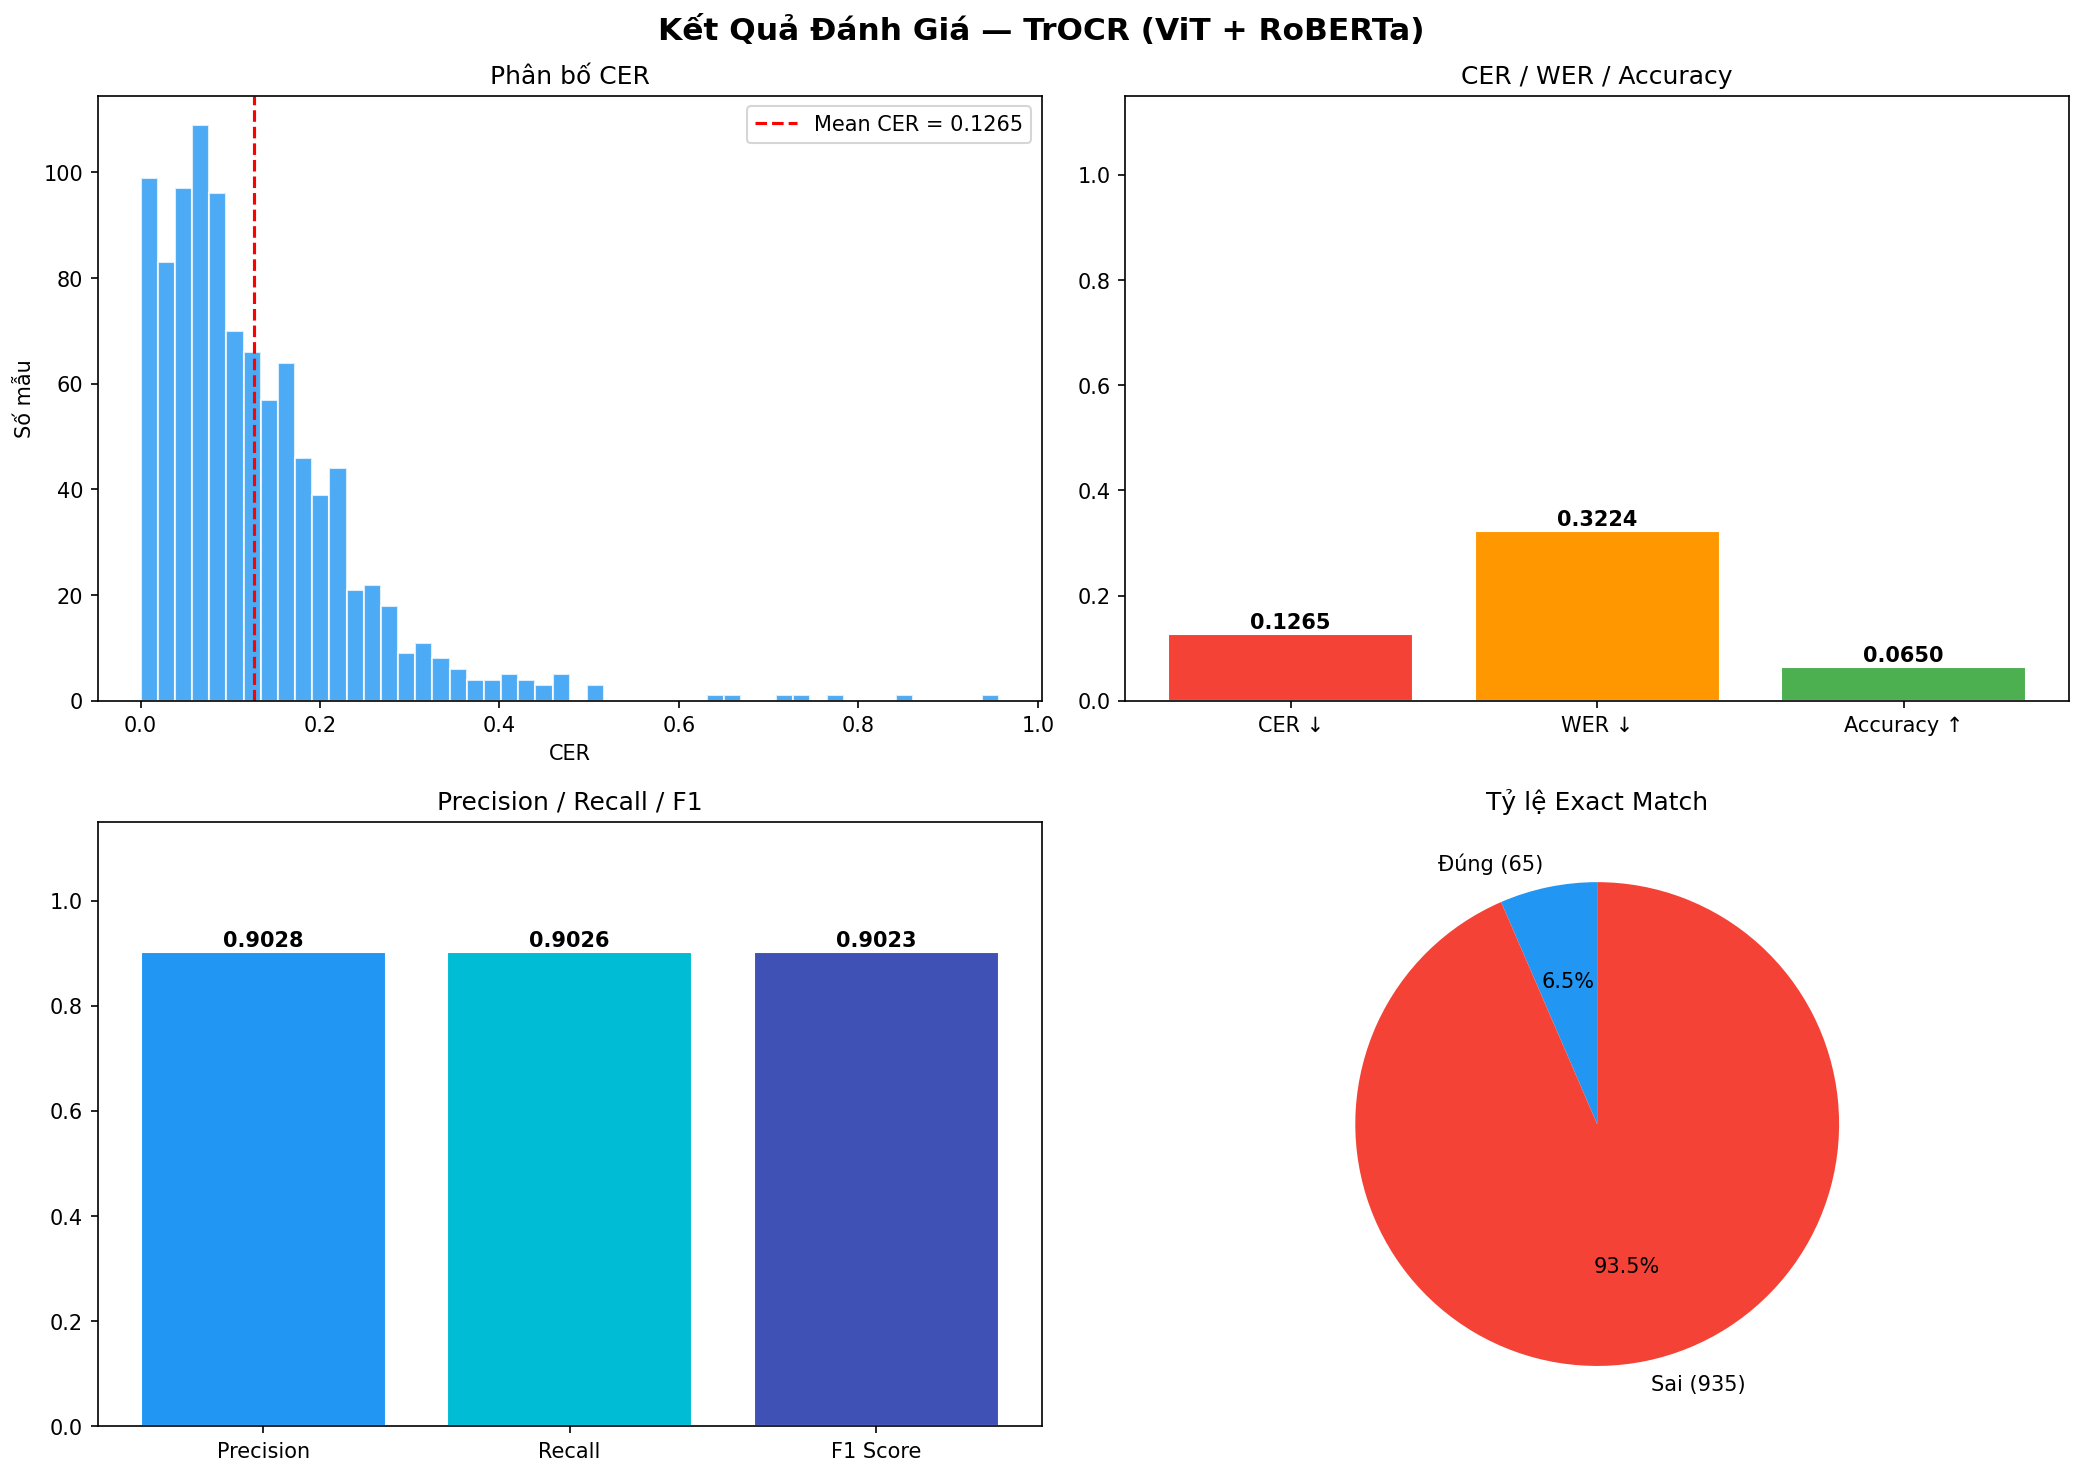

In [ ]:
from IPython.display import Image, display
import os

print("="*40)
print(" BIỂU ĐỒ TRAINING LOSS & VALIDATION LOSS")
print("="*40)
if os.path.exists("results_trocr/trocr_loss_curve.png"):
    display(Image("results_trocr/trocr_loss_curve.png"))
else:
    print("Chưa có biểu đồ Loss (Có thể mô hình chưa train xong hoặc bị lỗi giữa chừng).")

print("\n" + "="*40)
print(" BIỂU ĐỒ KẾT QUẢ ĐÁNH GIÁ (CER, WER, EXACT MATCH)")
print("="*40)
if os.path.exists("results_trocr/trocr_results.png"):
    display(Image("results_trocr/trocr_results.png"))
else:
    print("Chưa có biểu đồ Metrics (Bạn phải chạy xong bước Evaluate mới sinh ra ảnh này).")


In [ ]:
# CELL TEST
import os
import time
import torch
import matplotlib.pyplot as plt
from PIL import Image as PILImage

print("[INFO] Đang khởi tạo cấu hình...")
config = Config()
config.DO_TRAIN = False

print("[INFO] Đang tải mô hình TrOCR (sẽ mất khoảng 1-2 phút)...")
model = TrOCRWrapper(config)

def test_trocr_interactive(model):
    print("\n" + "=" * 60)
    print("DEMO NHẬN DẠNG ẢNH BẰNG TrOCR (CHỈ HỖ TRỢ TRÊN GOOGLE COLAB)")
    print("=" * 60)

    try:
        from google.colab import files
    except ImportError:
        print("[LỖI] Tính năng upload ảnh này chỉ hoạt động trên Google Colab.")
        return

    print("Vui lòng chọn ảnh từ máy tính để tải lên...")
    uploaded = files.upload()

    if not uploaded:
        print("Không có ảnh nào được tải lên.")
        return

    for filename in uploaded.keys():
        print(f"\n[INFO] Đang xử lý ảnh: {filename}")
        try:
            image = PILImage.open(filename).convert("RGB")


            plt.figure(figsize=(8, 4))
            plt.imshow(image)
            plt.axis('off')
            plt.title("Ảnh đầu vào TrOCR")
            plt.show()


            start_time = time.time()
            prediction = model.predict(image)
            inference_time = time.time() - start_time

            print("\n" + "-" * 50)
            print(f"Thời gian nhận dạng: {inference_time:.2f}s")
            print(f"KẾT QUẢ DỰ ĐOÁN (TrOCR): \n{prediction}")
            print("-" * 50)

        except Exception as e:
            print(f"[LỖI] Không thể xử lý ảnh {filename}: {e}")


test_trocr_interactive(model)


[INFO] Đang khởi tạo cấu hình...
[INFO] Đang tải mô hình TrOCR (sẽ mất khoảng 1-2 phút)...
[MODEL] Đang tải TrOCR từ microsoft/trocr-base-handwritten...
[MODEL] Tìm thấy checkpoint: /content/drive/MyDrive/checkpoint-3000. Khởi tạo mô hình từ đây...


Loading weights:   0%|          | 0/480 [00:00<?, ?it/s]

[MODEL] TrOCR loaded
[MODEL] Tổng params     : 333,921,792
[MODEL] Trainable params: 333,921,792
[MODEL] VRAM sau load   : 2.69 GB

DEMO NHẬN DẠNG ẢNH BẰNG TrOCR (CHỈ HỖ TRỢ TRÊN GOOGLE COLAB)
Vui lòng chọn ảnh từ máy tính để tải lên...


Saving image (2).jpg to image (2).jpg

[INFO] Đang xử lý ảnh: image (2).jpg

--------------------------------------------------
⏱️ Thời gian nhận dạng: 3.40s
📝 KẾT QUẢ DỰ ĐOÁN (TrOCR): 
đến mức muẫn tự tử được nhưng ko phải vĩ người
--------------------------------------------------
